<a href="https://colab.research.google.com/github/tdiya99-creator/GLA-Bootcamp/blob/main/b2_session7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
  #DATA points and distance

In [ ]:
#what is a vector
a vector list of numbers that have some parameters

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#study_hours, attendance, previous_marks
students_a= np.array([6,85,78])
students_b= np.array([3,70,55])

print("Students A vector:", students_a)
print("Students B vector:", students_b)

Students A vector: [ 6 85 78]
Students B vector: [ 3 70 55]


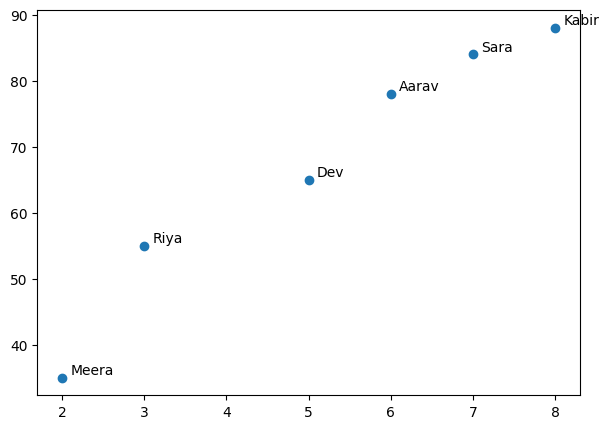

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

students = pd.DataFrame({
    "name": ["Aarav", "Riya", "Kabir", "Meera", "Dev", "Sara"],
    "study_hours": [6, 3, 8, 2, 5, 7],
    "attendance": [85, 70, 90, 60, 78, 92],
    "previous_marks": [78, 55, 88, 35, 65, 84],
    "final_marks": [82, 58, 91, 40, 70, 88]
})
#regression
#MAIN ACTOR

plt.figure(figsize=(7,5))

plt.scatter(
    students["study_hours"],
    students["previous_marks"]
)

for i, row in students.iterrows():
  plt.text(row["study_hours"]+0.1, row["previous_marks"]+0.5, row["name"])


In [4]:
#SIMILARITY and EMBEDDINGS
#DIATANCE and SIMILARITY
#similarity asks how close or related the two data points are
#distance asks how far apart the two points are

#Google photos- image similarity
#recomendation algos
#clustering is happening on the basis of similarity

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

students = pd.DataFrame({
    "name": ["Aarav", "Riya", "Kabir", "Meera", "Dev", "Sara"],
    "study_hours": [6, 3, 8, 2, 5, 7],
    "attendance": [85, 70, 90, 60, 78, 92],
    "previous_marks": [78, 55, 88, 35, 65, 84],
    "final_marks": [82, 58, 91, 40, 70, 88]
})

In [6]:
feature_columns=["study_hours", "attendance", "previous_marks"]
student_vectors=students[feature_columns].values
print(student_vectors)


[[ 6 85 78]
 [ 3 70 55]
 [ 8 90 88]
 [ 2 60 35]
 [ 5 78 65]
 [ 7 92 84]]


In [7]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix=cosine_similarity(student_vectors)

similarity_df=pd.DataFrame(
    similarity_matrix,
    index=students["name"],
    columns=students["name"]
)

similarity_df

name,Aarav,Riya,Kabir,Meera,Dev,Sara
name,,,,,,
Aarav,1.000000,0.996913,0.999434,0.976875,0.998860,0.999988
Riya,0.996913,1.000000,0.993724,0.990505,0.999467,0.997017
Kabir,0.999434,0.993724,1.000000,0.969344,0.996756,0.999391
Meera,0.976875,0.990505,0.969344,1.000000,0.985958,0.977304
Dev,0.998860,0.999467,0.996756,0.985958,1.000000,0.998956
Sara,0.999988,0.997017,0.999391,0.977304,0.998956,1.000000


In [8]:
#2 types of data
#client side
#reel meta data

#recomendation
#NLP
#vectors- n directions

In [10]:
#an embedding is a vector that represents meaning
#words, images, products, users, documents

In [11]:
# cat-dog || dog-banana || cat-bottle || monkey-banana

In [12]:
#Models do not read english directly
#tokens
#SOTA model (state of the art)

In [13]:
#1M realistically tackle questions or remember context

#2022 12k
#2026 1M
#2026 10M


In [14]:
#if the model ignores the order of tokens then meaning will be lost

#text--tokens--token ids--embeddiongs---model

In [15]:
sentence = "The movie was not good"

tokens = sentence.lower().split()

print(tokens)

['the', 'movie', 'was', 'not', 'good']


In [16]:
vocab = {
    "the": 1,
    "movie": 2,
    "was": 3,
    "not": 4,
    "good": 5
}
token_ids = [vocab [word] for word in tokens]

print(token_ids)

[1, 2, 3, 4, 5]


In [17]:
#text as a sequence data
#dog bitas man
#man bites dog

#same words, different order, different meanings


In [18]:
#I only said she stole my phone.
#Only I said she stole my phone.
#I said only she stole my phone.
#I said she only stole my phone.

Can i go
i can go

she saw him
he saw her

not bad
bad not

#positional encoding

SyntaxError: invalid syntax (2096545988.py, line 6)

In [19]:
sentences = [
    "dog bites man",
    "man bites dog",
    "the movie was good",
    "the movie was not good"
]

for sentence in sentences:
  print(sentence, "->", sentence.split())

dog bites man -> ['dog', 'bites', 'man']
man bites dog -> ['man', 'bites', 'dog']
the movie was good -> ['the', 'movie', 'was', 'good']
the movie was not good -> ['the', 'movie', 'was', 'not', 'good']


In [20]:

positive_words = ["good", "great", "amazing", "excellent", "love"]
negative_words = ["bad", "terrible", "poor", "hate", "boring"]

def simple_sentence(sentence):
  words = sentence.lower().replace(".", "").split()

  score = 0

  for word in words:
    if word in positive_words:
      score += 1
    elif word in negative_words:
      score -= 1

  if score>0:
    return "Positive"
  elif score<0:
    return "Negative"
  else:
    return "Neutral"

print(simple_sentence("The movie was good"))
print(simple_sentence("The movie was bad"))
print(simple_sentence("The movie was not good"))

Positive
Negative
Positive


In [21]:
positive_words = ["good", "great", "amazing", "excellent", "love"]
negative_words = ["bad", "terrible", "poor", "hate", "boring"]

def better_sentiment_with_not(sentence):
  words = sentence.lower().replace(".", "").split()

  score = 0

  for i, word in enumerate(words):
    previous_word=words[i-1] if i>0 else ""

    if word in positive_words:
      if previous_word=="not":
        score -= 1
      else:
        score+=1

    elif word in negative_words:
      if previous_word == "not":
        score += 1
      else:
        score -= 1

  if score>0:
    return "Positive"
  elif score<0:
    return "Negative"
  else:
    return "Neutral"

print(better_sentiment_with_not("The movie was good"))
print(better_sentiment_with_not("The movie was not good"))
print(better_sentiment_with_not("The movie was not bad"))


Positive
Negative
Positive


In [22]:
#RNN
#recurrent-- something repeats
#in RNN the same cell is used again and again across sequence
#each word enters the sequence one by one

In [23]:
#The movie was not good

#At time step t

#current input = x_t (current token)
#previous memory = h_(t-1) (updated memory)
#new_memory - h_t
#output = y_t-- positive intent (positive sentiment)